In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Video, clear_output

import cv2
import mediapipe as mp
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np

In [2]:
data = pd.read_csv('data/annotations.csv', sep='\t', on_bad_lines='skip')
data

,attachment_id,text,user_id,height,width,length,train,begin,end
0,44e8d2a0-7e01-450b-90b0-beb7400d2c1e,Ё,185bd3a81d9d618518d10abebf0d17a8,1920,1080,156.0,True,36,112
1,df5b08f0-41d1-4572-889c-8b893e71069b,А,185bd3a81d9d618518d10abebf0d17a8,1920,1080,150.0,True,36,76
2,17f53df4-c467-4aff-9f48-20687b63d49a,Р,185bd3a81d9d618518d10abebf0d17a8,1920,1080,133.0,True,40,97
3,e3add916-c708-4339-ad98-7e2740be29e9,Е,185bd3a81d9d618518d10abebf0d17a8,1920,1080,144.0,True,43,107
4,bd7272ed-1850-48f1-a2a8-c8fed523dc37,Ч,185bd3a81d9d618518d10abebf0d17a8,1920,1080,96.0,True,20,70
...,...,...,...,...,...,...,...,...,...
20395,nodca88242-2bc7-4a77-9d14-103aa1dacbd6,no_event,0041ec866777f12c384b64d8cd636277,1920,1080,42.0,False,0,42
20396,no7a7812b1-ae64-4402-9ebc-5b947edbd021,no_event,f5b82a9c82f6d870ec253e4c3fa96d83,1280,720,32.0,False,0,32
20397,no62a4df76-b48d-4f61-b6e8-bc4a1eb0cb61,no_event,4299b8ccf39ace57287b463fbe4a489b,1920,960,32.0,False,0,32
20398,no388a3f7c-3594-4332-bc78-b5b53190301d,no_event,c80b4e57f158f28299b2a89694c42329,1920,1080,41.0,False,0,41


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   attachment_id  20400 non-null  object 
 1   text           20400 non-null  object 
 2   user_id        20400 non-null  object 
 3   height         20400 non-null  int64  
 4   width          20400 non-null  int64  
 5   length         20400 non-null  float64
 6   train          20400 non-null  bool   
 7   begin          20400 non-null  int64  
 8   end            20400 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 1.3+ MB


In [4]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
attachment_id,20400,20400,no23f5da85-9fa5-4c80-b25b-11029d4f4753,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,20400,1001,no_event,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,20400,194,db573f94204e56e0cf3fc2ea000e5bdc,3692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,20400.0,NaN,NaN,NaN,1615.822843,412.571969,720.0,1280.0,1920.0,1920.0,1920.0
width,20400.0,NaN,NaN,NaN,1021.938431,254.156175,720.0,822.0,1080.0,1080.0,1920.0
length,20400.0,NaN,NaN,NaN,105.816961,28.029089,32.0,87.0,103.0,121.0,302.0
train,20400,2,True,15300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
begin,20400.0,NaN,NaN,NaN,16.670147,12.990868,0.0,8.0,14.0,23.0,132.0
end,20400.0,NaN,NaN,NaN,66.348578,21.512022,18.0,52.0,63.0,77.0,262.0


Мультиклассовая классификация - 1001 класс.

194 пользователя участвовало в записи.
height - высота видео
weight - ширина видео
length - длина видео (в кадрах)
begin - начало жеста на видео (в кадрах)
end - конец жеста на видео (в кадрах)

In [5]:
data['text'].value_counts()

text
no_event          400
отложить           20
З                  20
Ё                  20
А                  20
                 ... 
башенные часы      20
в то время как     20
время 11 часов     20
навсегда           20
2 часа             20
Name: count, Length: 1001, dtype: int64

In [6]:
data[data['train'] == True]['text'].value_counts()

text
no_event          300
отложить           15
З                  15
Ё                  15
А                  15
                 ... 
башенные часы      15
в то время как     15
время 11 часов     15
навсегда           15
2 часа             15
Name: count, Length: 1001, dtype: int64

In [7]:
data[data['train'] == False]['text'].value_counts()

text
no_event               100
временный                5
Щ                        5
Д                        5
Т                        5
                      ... 
расписание               5
еще нет                  5
2 часа                   5
время для измерений      5
в прошлом году           5
Name: count, Length: 1001, dtype: int64

In [8]:
data['duration'] = data['end'] - data['begin']

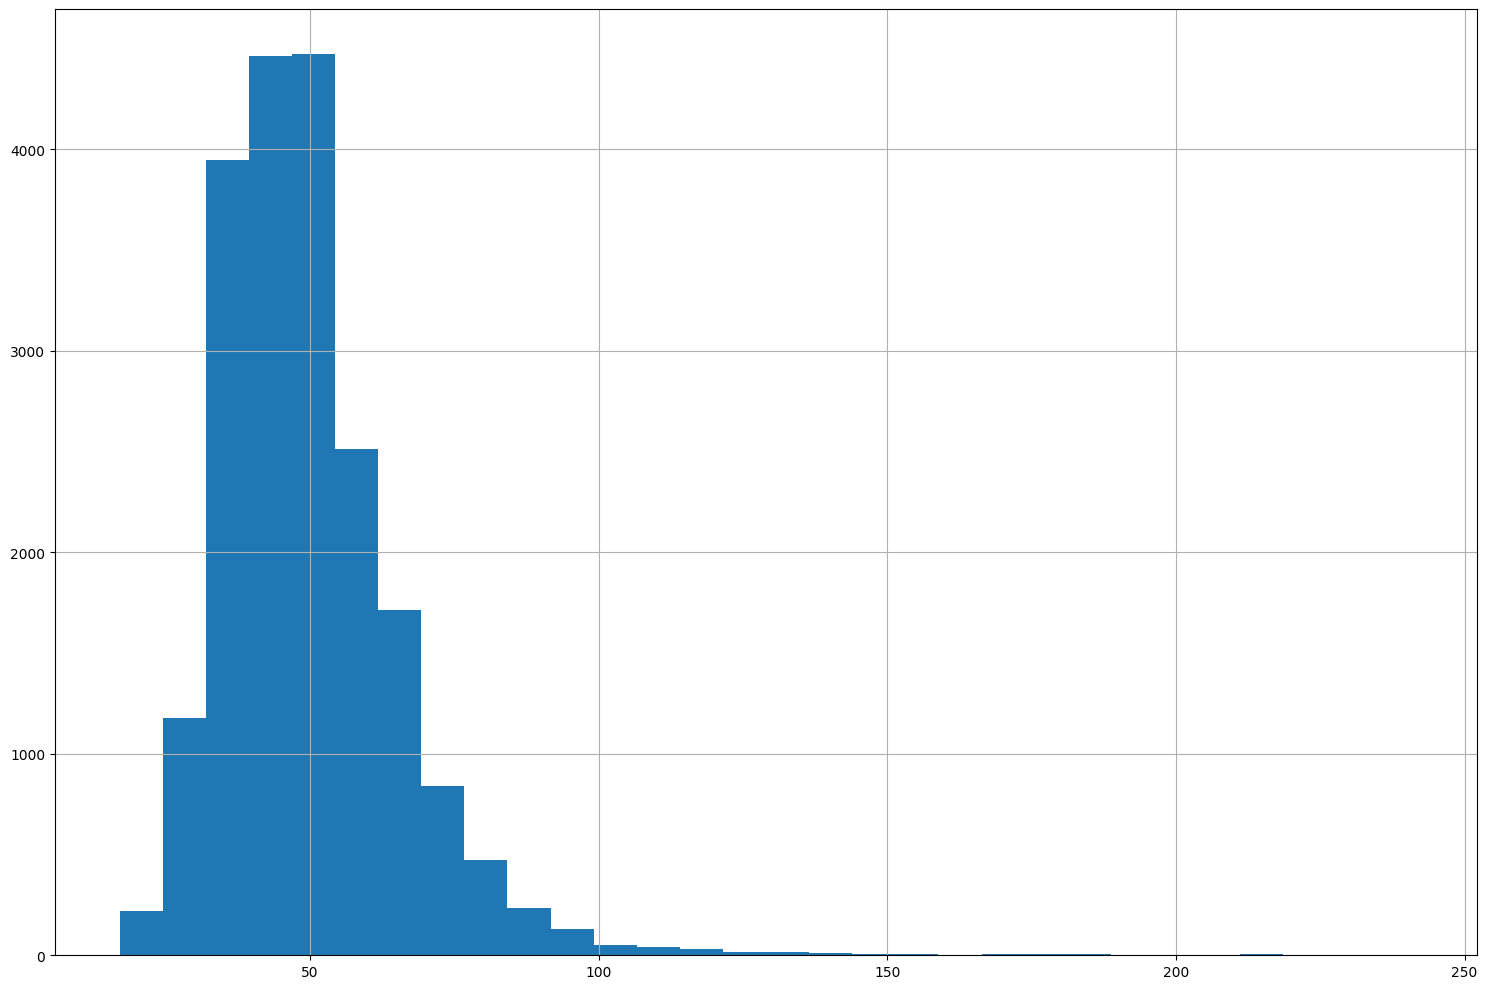

In [9]:
data['duration'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [10]:
data['duration'].describe()

count    20400.000000
mean        49.678431
std         16.140059
min         17.000000
25%         39.000000
50%         47.000000
75%         57.000000
max        241.000000
Name: duration, dtype: float64

In [11]:
data['duration'].median()

np.float64(47.0)

In [12]:
gesture_lengths = data.groupby("text")["duration"].describe()
gests = gesture_lengths[["min", "mean", "max"]]

<Axes: >

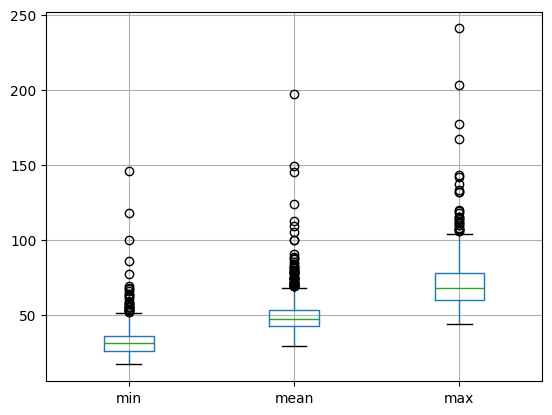

In [13]:
gests.boxplot()

Каждый жест может длиться по разному. Есть короткие жесты, есть средние, а есть длинные.
Модель не может принимать разную длину последовательности, поэтому нужно выбрать какое-то ограничение.

<Axes: ylabel='Frequency'>

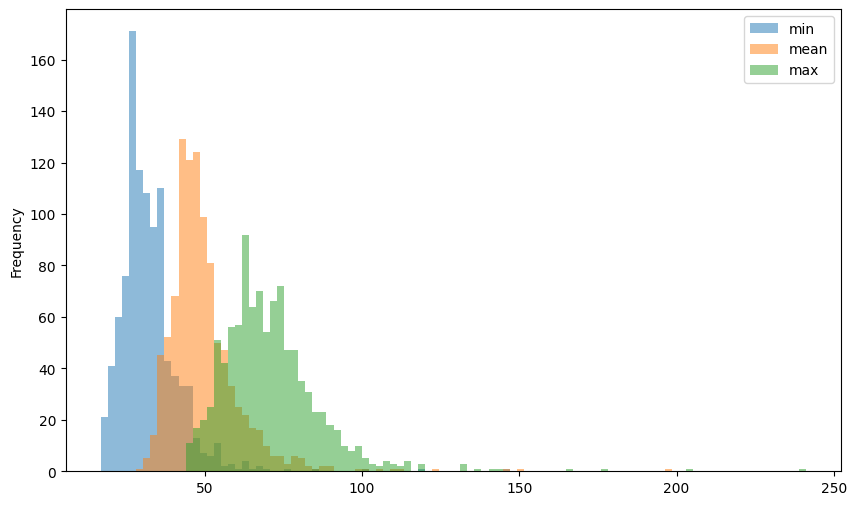

In [14]:
gests.plot(
    kind='hist', 
    bins=100, 
    alpha=0.5, 
    figsize=(10,6)
)

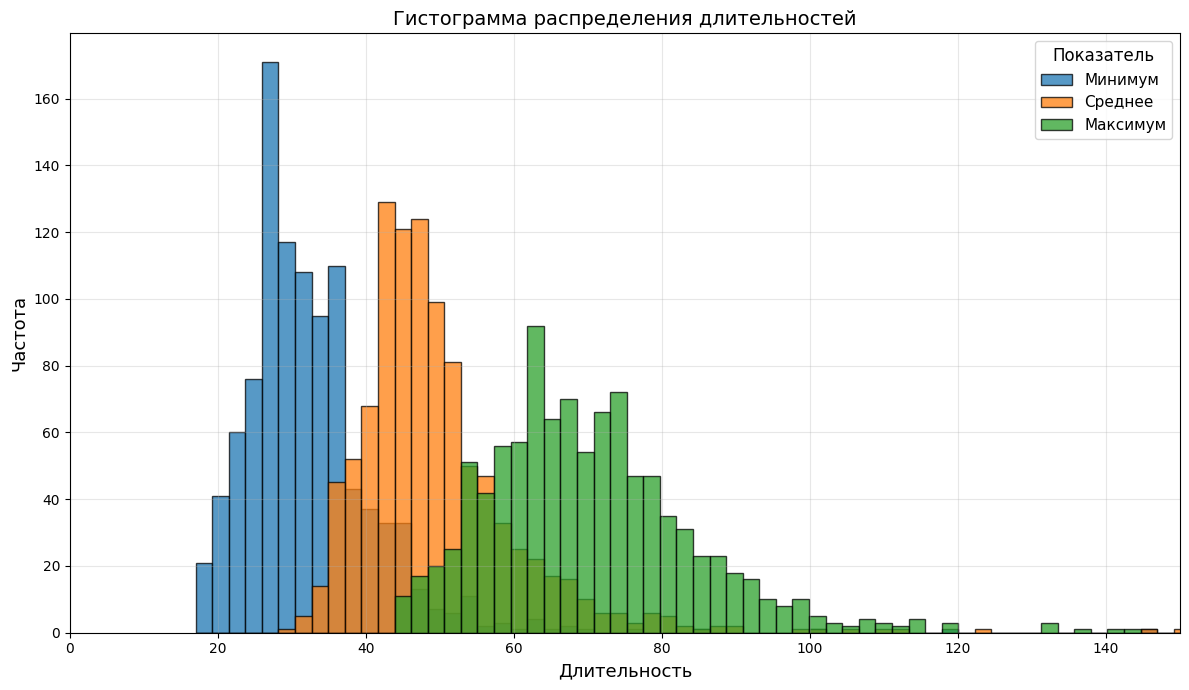

In [19]:
ax = gests.plot(
    kind='hist', 
    bins=100,
    alpha=0.75,
    figsize=(12, 7),
    edgecolor='black'
)

# Настройка осей и заголовка
ax.set_xlim(0, 150)
ax.set_title('Гистограмма распределения длительностей', fontsize=14)
ax.set_xlabel('Длительность', fontsize=13)
ax.set_ylabel('Частота', fontsize=13)

# ←←← ИЗМЕНЕНИЕ ЛЕГЕНДЫ ←←←
ax.legend(['Минимум', 'Среднее', 'Максимум'], 
          title='Показатель', 
          fontsize=11,
          title_fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('гистограмма_длительностей.png', dpi=300, bbox_inches='tight')

plt.show()

In [40]:
data.shape

(20400, 10)

In [44]:
all_s = data.shape[0]
for i in [2**d for d in range(3, 10)]:
    s = data[data['duration'] <= i].shape[0]
    print(f'для {i}-ых кадров покрытие = {s/all_s * 100} %')

для 8-ых кадров покрытие = 0.0 %
для 16-ых кадров покрытие = 0.0 %
для 32-ых кадров покрытие = 8.84313725490196 %
для 64-ых кадров покрытие = 86.0 %
для 128-ых кадров покрытие = 99.6421568627451 %
для 256-ых кадров покрытие = 100.0 %
для 512-ых кадров покрытие = 100.0 %


Все жесты находятся между 32 и 128 кадрами.

In [47]:
all_s = data.shape[0]
for i in [32 + 8*d for d in range(0, 14)]:
    s = data[data['duration'] <= i].shape[0]
    print(f'для {i}-ых кадров покрытие = {s/all_s * 100} %')

для 32-ых кадров покрытие = 8.84313725490196 %
для 40-ых кадров покрытие = 29.171568627450977 %
для 48-ых кадров покрытие = 54.09803921568628 %
для 56-ых кадров покрытие = 74.26960784313725 %
для 64-ых кадров покрытие = 86.0 %
для 72-ых кадров покрытие = 92.73529411764706 %
для 80-ых кадров покрытие = 96.23039215686275 %
для 88-ых кадров покрытие = 97.88725490196079 %
для 96-ых кадров покрытие = 98.73039215686275 %
для 104-ых кадров покрытие = 99.1470588235294 %
для 112-ых кадров покрытие = 99.38725490196079 %
для 120-ых кадров покрытие = 99.5686274509804 %
для 128-ых кадров покрытие = 99.6421568627451 %
для 136-ых кадров покрытие = 99.72549019607844 %


Будем использовать последовательности жестов из 96 кадров:
 - покрытие около 98,7 % жестов
 - можно использовать downsampling, и данные не станут слишком короткие
 - Обработка в real-time будет около 3 секунд при 30fps, что хорошо для real-time модели.


При проектировании приложения стало ясно, что нужно уменьшать длину последовательности для модели. Поэтому мы будем брать не каждый кадр, а каждый 2ой.

In [ ]:
gests['mean'].describe()

In [30]:
gests['mean'].describe()

count    1001.000000
mean       49.684903
std        12.315876
min        29.650000
25%        42.850000
50%        47.350000
75%        53.250000
max       197.650000
Name: mean, dtype: float64